<a href="https://colab.research.google.com/github/baoan056788/THDeppLearning/blob/main/Week2_LinearRegressionAndANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression with PyTorch: Babies Dataset

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

## 2. Load and Inspect the Data (`babies.txt`)

In [ ]:
file_path = '/content/babies.txt'

# Load the data, assuming space-separated values and a header
try:
    df_babies = pd.read_csv(file_path, sep=r'\s+')
    print("Successfully loaded babies.txt")
except Exception as e:
    print(f"Error loading file: {e}")
    # Fallback if the first attempt fails (e.g., no header)
    df_babies = pd.read_csv(file_path, sep=r'\s+', header=None)
    df_babies.columns = ['bwt', 'smoke'] # Manually assign column names
    print("Loaded without header and assigned 'bwt', 'smoke' as columns.")

print("\nFirst 5 rows of the dataset:")
display(df_babies.head())

print("\nDataset Information:")
df_babies.info()

print("\nDescriptive Statistics:")
display(df_babies.describe())

Successfully loaded babies.txt

First 5 rows of the dataset:


,bwt,smoke
0,120,0
1,113,0
2,128,1
3,123,0
4,108,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   bwt     1236 non-null   int64
 1   smoke   1236 non-null   int64
dtypes: int64(2)
memory usage: 19.4 KB

Descriptive Statistics:


,bwt,smoke
count,1236.000000,1236.000000
mean,119.576861,0.464401
std,18.236452,0.912102
min,55.000000,0.000000
25%,108.750000,0.000000
50%,120.000000,0.000000
75%,131.000000,1.000000
max,176.000000,9.000000


## 3. Data Preparation

In [ ]:
# Define feature (X) and target (y)
feature_col = 'smoke'
target_col = 'bwt'

df_cleaned = df_babies[[feature_col, target_col]].dropna()

X_np = df_cleaned[feature_col].values.astype(np.float32).reshape(-1, 1)
y_np = df_cleaned[target_col].values.astype(np.float32).reshape(-1, 1)

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_np)

X = torch.tensor(X_normalized, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

print(f"\nShape of X (normalized {feature_col}): {X.shape}")
print(f"Shape of y ({target_col}): {y.shape}")


Shape of X (normalized smoke): torch.Size([1236, 1])
Shape of y (bwt): torch.Size([1236, 1])


### 3.1 Visualize Prepared Data

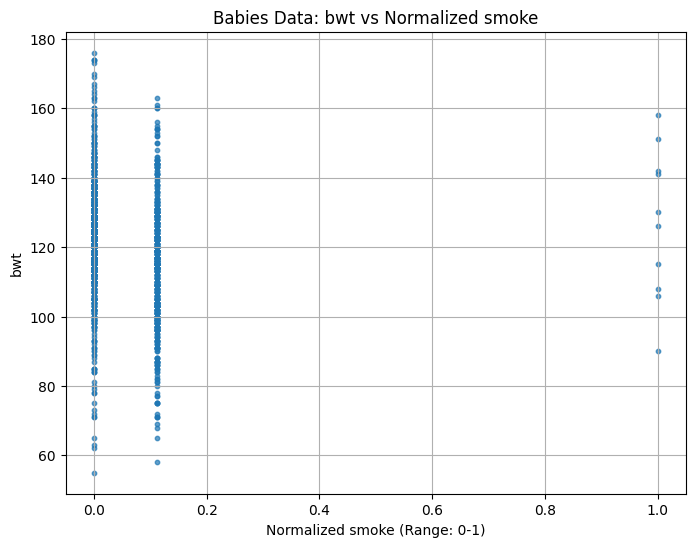

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X.numpy(), y.numpy(), s=10, alpha=0.7)
plt.title(f'Babies Data: {target_col} vs Normalized {feature_col}')
plt.xlabel(f'Normalized {feature_col} (Range: 0-1)')
plt.ylabel(f'{target_col}')
plt.grid(True)
plt.show()

## 4. Split Data into Training and Testing Sets

In [ ]:
# Split the data into training and testing sets
# test_size=0.2 20% 80% for training

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: torch.Size([988, 1])
Shape of y_train: torch.Size([988, 1])
Shape of X_test: torch.Size([248, 1])
Shape of y_test: torch.Size([248, 1])


## 5. Define the Linear Regression Model

In [ ]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)

input_size = X_train.shape[1]
output_size = y_train.shape[1]

model = LinearRegressionModel(input_size, output_size)
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


## 6. Define Loss Function and Optimizer

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## 7. Train the Model

In [ ]:
num_epochs = 100
loss_history_train = []
loss_history_test = [] # Track test loss as well

for epoch in range(num_epochs):
    # Set model to training mode
    model.train()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history_train.append(loss.item())

    # Evaluate on test set (no gradient calculations)
    model.eval()
    with torch.no_grad():
        outputs_test = model(X_test)
        test_loss = criterion(outputs_test, y_test)
        loss_history_test.append(test_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

print("\nTraining complete!")
print(f"Final Training Loss: {loss_history_train[-1]:.4f}")
print(f"Final Test Loss: {loss_history_test[-1]:.4f}")

# Print learned parameters
print("\nLearned parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data.numpy()}")

Epoch [10/100], Training Loss: 10388.8721, Test Loss: 9597.0361
Epoch [20/100], Training Loss: 7034.4897, Test Loss: 6462.4648
Epoch [30/100], Training Loss: 4797.4019, Test Loss: 4385.2637
Epoch [40/100], Training Loss: 3305.4519, Test Loss: 3010.7964
Epoch [50/100], Training Loss: 2310.4434, Test Loss: 2103.0007
Epoch [60/100], Training Loss: 1646.8514, Test Loss: 1504.8070
Epoch [70/100], Training Loss: 1204.2864, Test Loss: 1111.7640
Epoch [80/100], Training Loss: 909.1266, Test Loss: 854.4542
Epoch [90/100], Training Loss: 712.2737, Test Loss: 686.7816
Epoch [100/100], Training Loss: 580.9829, Test Loss: 578.1663

Training complete!
Final Training Loss: 580.9829
Final Test Loss: 578.1663

Learned parameters:
linear.weight: [[5.7320666]]
linear.bias: [103.87418]


8. Evaluate the Model

In [ ]:
model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation for evaluation
    outputs_test = model(X_test)
    loss_test = criterion(outputs_test, y_test)
    print(f"Test Loss: {loss_test.item():.4f}")

Test Loss: 578.1663


## 8.1 Model Evaluation: Loss and Accuracy Comparison

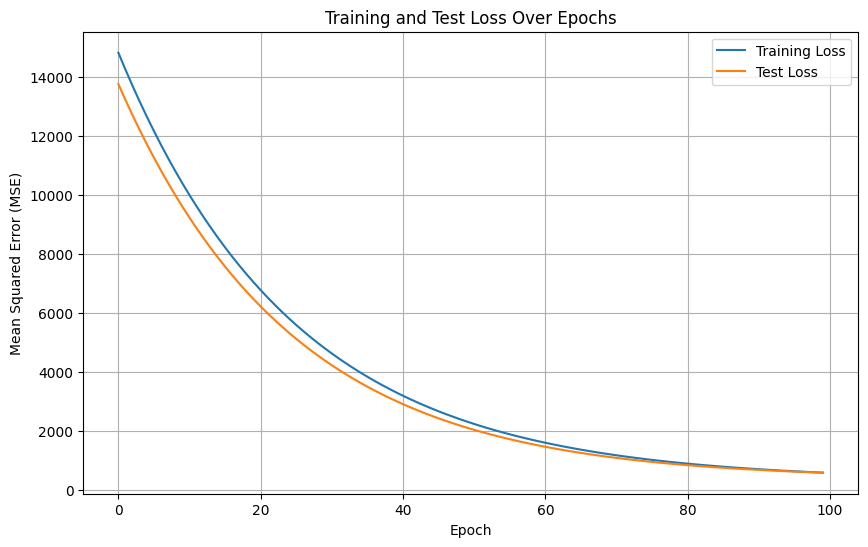

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), loss_history_train, label='Training Loss')
plt.plot(range(num_epochs), loss_history_test, label='Test Loss')
plt.title('Training and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

# Convert tensors to numpy arrays for scikit-learn metrics
y_train_np = y_train.numpy()
y_test_np = y_test.numpy()

# Ensure model is in evaluation mode before making predictions
model.eval()
with torch.no_grad():
    predicted_train_np = model(X_train).numpy()
    predicted_test_np = model(X_test).numpy()

# Calculate MAE for training set
mae_train = mean_absolute_error(y_train_np, predicted_train_np)
print(f"Mean Absolute Error (Training Set): {mae_train:.4f}")

# Calculate MAE for test set
mae_test = mean_absolute_error(y_test_np, predicted_test_np)
print(f"Mean Absolute Error (Test Set): {mae_test:.4f}")

Mean Absolute Error (Training Set): 19.6965
Mean Absolute Error (Test Set): 19.5975


## 9.1 Visualize the Linear Regression Fit (Train vs Test)

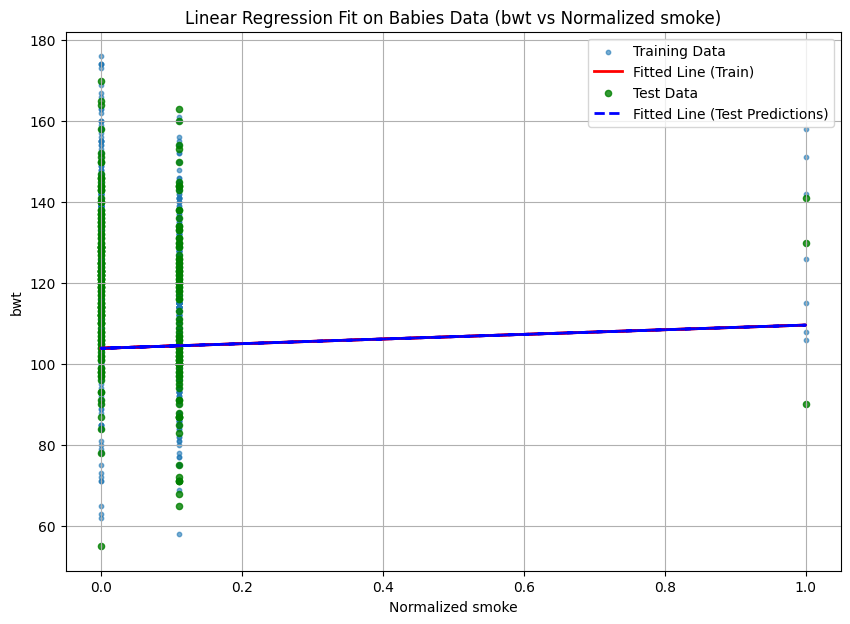

In [ ]:
model.eval()
with torch.no_grad():
    predicted_train = model(X_train).numpy()
    predicted_test = model(X_test).numpy()

plt.figure(figsize=(10, 7))

# Plot training data and its fitted line
plt.scatter(X_train.numpy(), y_train.numpy(), s=10, alpha=0.6, label='Training Data')
plt.plot(X_train.numpy(), predicted_train, color='red', linestyle='-', linewidth=2, label='Fitted Line (Train)')

# Plot test data and its fitted predictions
plt.scatter(X_test.numpy(), y_test.numpy(), s=20, color='green', alpha=0.8, label='Test Data')
plt.plot(X_test.numpy(), predicted_test, color='blue', linestyle='--', linewidth=2, label='Fitted Line (Test Predictions)')

plt.title(f'Linear Regression Fit on Babies Data ({target_col} vs Normalized {feature_col})')
plt.xlabel(f'Normalized {feature_col}')
plt.ylabel(f'{target_col}')
plt.legend()
plt.grid(True)
plt.show()

ANN

## 9. Artificial Neural Network (ANN) Model

### 9.1 Define the ANN Model Architecture

In [ ]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Define hyperparameters for the ANN
input_size_ann = X_train.shape[1]
hidden_size = 64 # You can experiment with different hidden layer sizes
output_size_ann = y_train.shape[1]

ann_model = ANNModel(input_size_ann, hidden_size, output_size_ann)
print(ann_model)

ANNModel(
  (fc1): Linear(in_features=1, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


### 9.2 Define Loss Function and Optimizer for ANN

In [ ]:
criterion_ann = nn.MSELoss()
optimizer_ann = torch.optim.Adam(ann_model.parameters(), lr=0.001) # Using Adam optimizer for ANN

### 9.3 Train the ANN Model

In [ ]:
num_epochs_ann = 200 # More epochs might be needed for ANN
loss_history_train_ann = []
loss_history_test_ann = []

for epoch in range(num_epochs_ann):
    # Set model to training mode
    ann_model.train()

    # Forward pass
    outputs_ann = ann_model(X_train)
    loss_ann = criterion_ann(outputs_ann, y_train)

    # Backward and optimize
    optimizer_ann.zero_grad()
    loss_ann.backward()
    optimizer_ann.step()

    loss_history_train_ann.append(loss_ann.item())

    # Evaluate on test set (no gradient calculations)
    ann_model.eval()
    with torch.no_grad():
        outputs_test_ann = ann_model(X_test)
        test_loss_ann = criterion_ann(outputs_test_ann, y_test)
        loss_history_test_ann.append(test_loss_ann.item())

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_ann}], Training Loss ANN: {loss_ann.item():.4f}, Test Loss ANN: {test_loss_ann.item():.4f}')

print("\nANN Training complete!")
print(f"Final ANN Training Loss: {loss_history_train_ann[-1]:.4f}")
print(f"Final ANN Test Loss: {loss_history_test_ann[-1]:.4f}")

Epoch [20/200], Training Loss ANN: 14642.7061, Test Loss ANN: 14144.9512
Epoch [40/200], Training Loss ANN: 14551.0654, Test Loss ANN: 14054.6973
Epoch [60/200], Training Loss ANN: 14454.4268, Test Loss ANN: 13959.3740
Epoch [80/200], Training Loss ANN: 14349.7490, Test Loss ANN: 13855.9639
Epoch [100/200], Training Loss ANN: 14235.1367, Test Loss ANN: 13742.6348
Epoch [120/200], Training Loss ANN: 14108.2344, Test Loss ANN: 13617.1504
Epoch [140/200], Training Loss ANN: 13967.8164, Test Loss ANN: 13478.1641
Epoch [160/200], Training Loss ANN: 13812.2432, Test Loss ANN: 13324.1934
Epoch [180/200], Training Loss ANN: 13640.4258, Test Loss ANN: 13153.9678
Epoch [200/200], Training Loss ANN: 13447.4209, Test Loss ANN: 12962.9951

ANN Training complete!
Final ANN Training Loss: 13447.4209
Final ANN Test Loss: 12962.9951


### 9.4 Evaluate the ANN Model

ANN Test Loss: 12962.9951


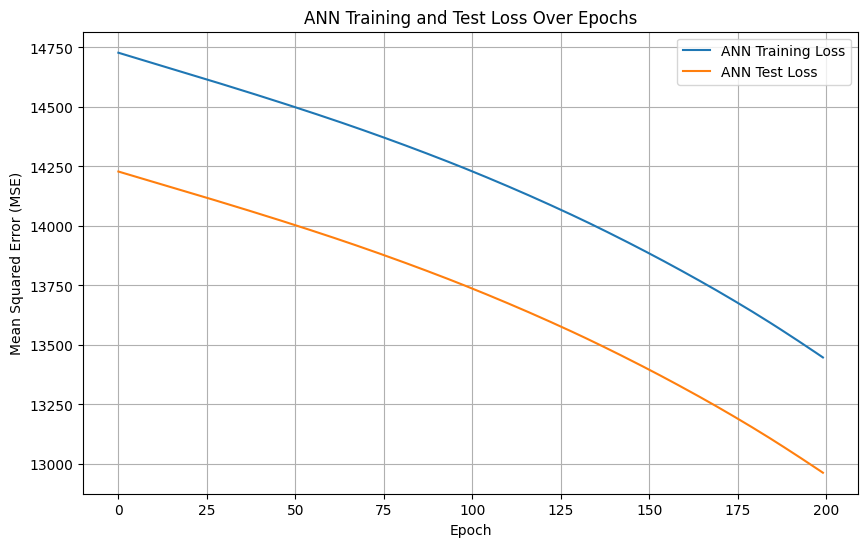

Mean Absolute Error (ANN Training Set): 114.5438
Mean Absolute Error (ANN Test Set): 112.1010


In [ ]:
ann_model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation for evaluation
    outputs_test_ann = ann_model(X_test)
    loss_test_ann = criterion_ann(outputs_test_ann, y_test)
    print(f"ANN Test Loss: {loss_test_ann.item():.4f}")

# Plot Training and Test Loss for ANN
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs_ann), loss_history_train_ann, label='ANN Training Loss')
plt.plot(range(num_epochs_ann), loss_history_test_ann, label='ANN Test Loss')
plt.title('ANN Training and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()
plt.show()

# Calculate MAE for ANN
predicted_train_ann_np = ann_model(X_train).detach().numpy()
predicted_test_ann_np = ann_model(X_test).detach().numpy()

mae_train_ann = mean_absolute_error(y_train_np, predicted_train_ann_np)
print(f"Mean Absolute Error (ANN Training Set): {mae_train_ann:.4f}")

mae_test_ann = mean_absolute_error(y_test_np, predicted_test_ann_np)
print(f"Mean Absolute Error (ANN Test Set): {mae_test_ann:.4f}")

### 9.5 Visualize the ANN Regression Fit (Train vs Test)

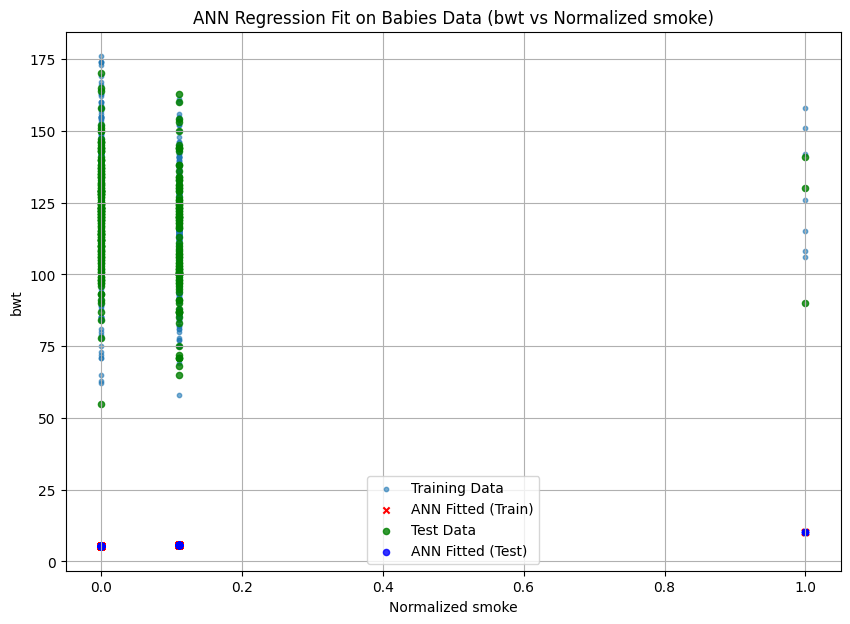

In [ ]:
ann_model.eval()
with torch.no_grad():
    predicted_train_ann = ann_model(X_train).numpy()
    predicted_test_ann = ann_model(X_test).numpy()

plt.figure(figsize=(10, 7))

# Plot training data and its fitted line
plt.scatter(X_train.numpy(), y_train.numpy(), s=10, alpha=0.6, label='Training Data')
plt.scatter(X_train.numpy(), predicted_train_ann, color='red', marker='x', s=20, label='ANN Fitted (Train)')

# Plot test data and its fitted predictions
plt.scatter(X_test.numpy(), y_test.numpy(), s=20, color='green', alpha=0.8, label='Test Data')
plt.scatter(X_test.numpy(), predicted_test_ann, color='blue', marker='o', s=20, alpha=0.8, label='ANN Fitted (Test)')

plt.title(f'ANN Regression Fit on Babies Data ({target_col} vs Normalized {feature_col})')
plt.xlabel(f'Normalized {feature_col}')
plt.ylabel(f'{target_col}')
plt.legend()
plt.grid(True)
plt.show()